In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [111]:
clean_visits = pd.read_csv("../data/clean/visitation_data_clean.csv")
national_parks = pd.read_csv("../data/clean/national_parks_clean.csv")
combined = pd.read_csv("../data/clean/combined_nps_visitation.csv")
combined.head()

,Park Name,Unit Code,Park Type,Region,Year,Month,Recreation Visits,Non Recreation Visits,Recreation Hours,Non Recreation Hours,...,Miscellaneous Overnight Stays,All Campers,Park,State,Latitude,Longitude,Park Code,Activities,Number of Activities,Entrance Fees
0,Acadia NP,acad,National Park,Northeast,2015,1,12578,600,83017,600,...,0,0,Acadia National Park,ME,44.409286,-68.247501,acad,"Arts and Culture,Cultural Demonstrations,Astro...",46,6.0
1,Acadia NP,acad,National Park,Northeast,2015,2,10626,600,70132,600,...,0,0,Acadia National Park,ME,44.409286,-68.247501,acad,"Arts and Culture,Cultural Demonstrations,Astro...",46,6.0
2,Acadia NP,acad,National Park,Northeast,2015,3,18062,600,119207,600,...,0,0,Acadia National Park,ME,44.409286,-68.247501,acad,"Arts and Culture,Cultural Demonstrations,Astro...",46,6.0
3,Acadia NP,acad,National Park,Northeast,2015,4,63214,600,366642,600,...,0,0,Acadia National Park,ME,44.409286,-68.247501,acad,"Arts and Culture,Cultural Demonstrations,Astro...",46,6.0
4,Acadia NP,acad,National Park,Northeast,2015,5,187205,7500,1062976,7500,...,753,12029,Acadia National Park,ME,44.409286,-68.247501,acad,"Arts and Culture,Cultural Demonstrations,Astro...",46,6.0


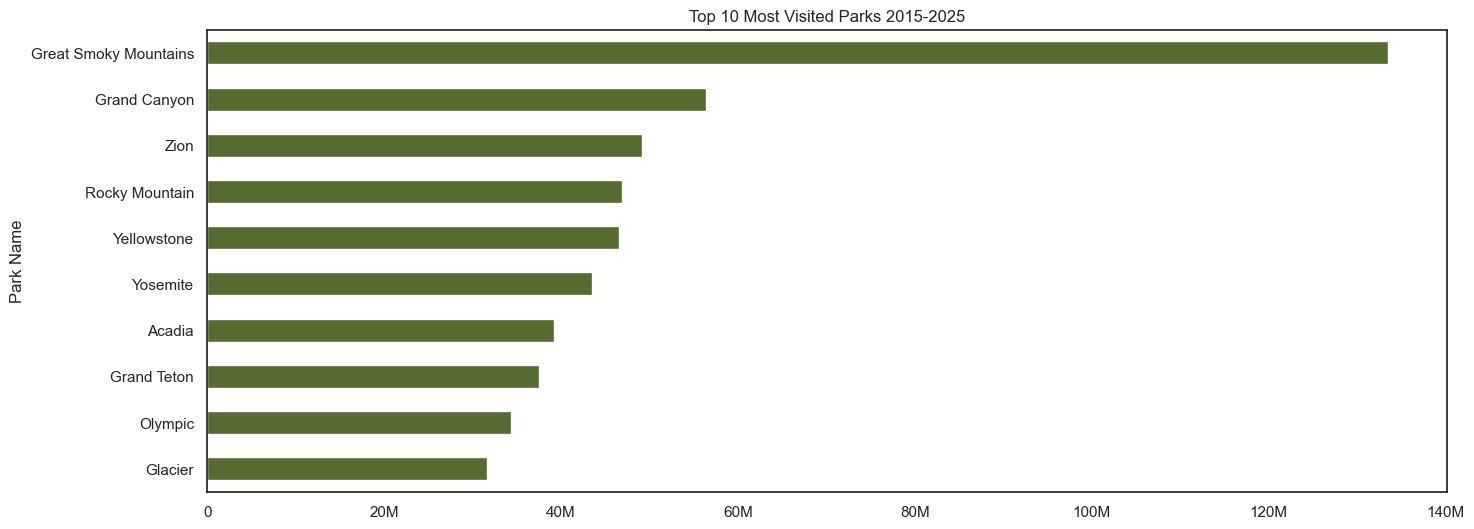

In [26]:
#top 10 parks by visitation numbers
sns.set_theme(style="white", palette="Greens")
park_vis = clean_visits.groupby('Park Name')['Recreation Visits'].sum()
top_park_vis = park_vis.sort_values(ascending=False).head(10)
top_park_vis.index = top_park_vis.index.str.replace(' NP', '', regex=False)
plt.figure(figsize=(16,6))
top_park_vis.sort_values().plot(kind='barh', color ='forestgreen')
plt.title("Top 10 Most Visited Parks 2015-2025")
plt.xlabel("Total Recreational Visits")
ax = top_park_vis.sort_values().plot(kind='barh',color='darkolivegreen')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: '0' if x == 0 else f'{x/1e6:.0f}M'))
plt.show()

Text(0.5, 1.0, 'Recreation Visits over Years 2015-2025')

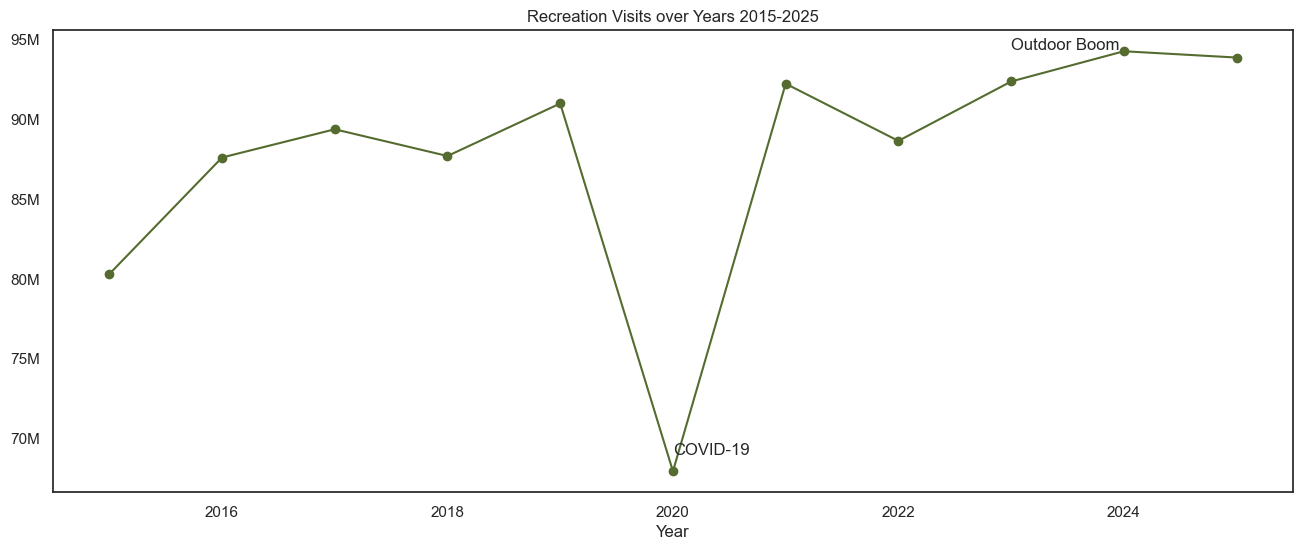

In [65]:
#Visitation Over Time
yearly_visits = clean_visits.groupby('Year')['Recreation Visits'].sum()
plt.figure(figsize=(16,6))
year_vis = yearly_visits.plot(kind='line', marker='o',color='darkolivegreen')
year_vis.annotate('COVID-19',xy=(2020, yearly_visits.loc[2020]),xytext=(2020, yearly_visits.loc[2020] +1_000_000))
year_vis.annotate('Outdoor Boom',xy=(2023, yearly_visits.loc[2023]),xytext=(2023, yearly_visits.loc[2023] +2_000_000))
year_vis.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: '0' if y == 0 else f'{y/1e6:.0f}M'))
plt.title('Recreation Visits over Years 2015-2025')

Text(0.5, 1.0, 'Monthly Visitation')

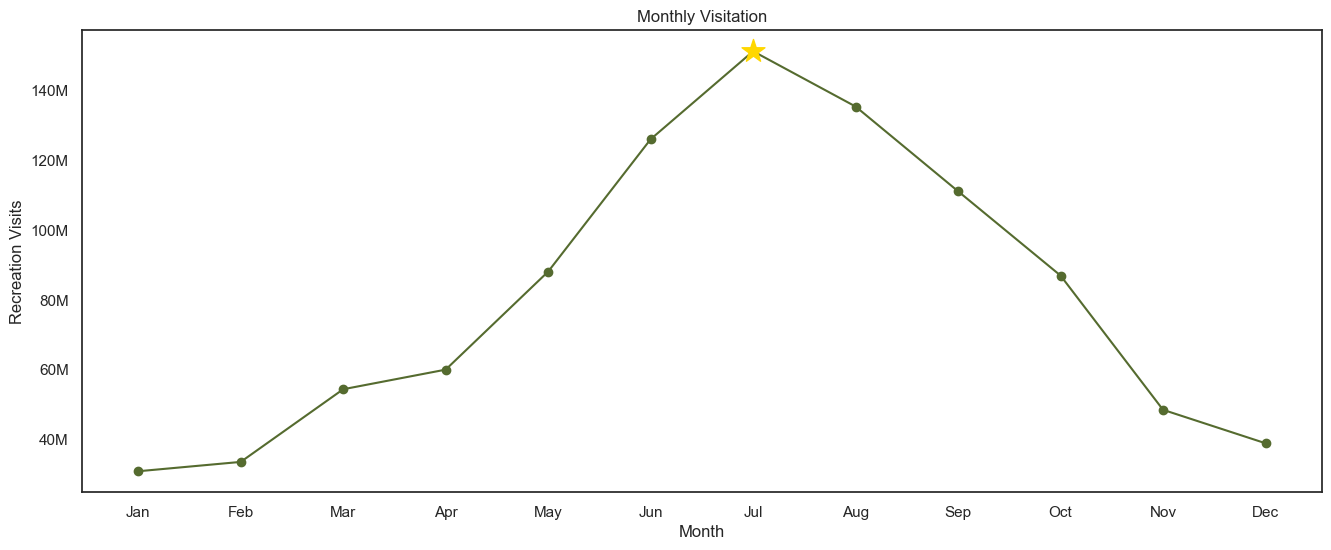

In [84]:
#Monthly Visitation
monthly_visits = clean_visits.groupby('Month')['Recreation Visits'].sum()
plt.figure(figsize=(16,6))
month_vis = monthly_visits.plot(kind='line', marker='o',color='darkolivegreen')
month_vis.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: '0' if y == 0 else f'{y/1e6:.0f}M'))
july_val = monthly_visits.loc[7]
plt.ylabel('Recreation Visits')
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(ticks=range(1, 13),labels=month_names)
plt.scatter(7,july_val,marker='*',s=300,color='gold',zorder=5) #star to depict that July is the most popular month to visit national parks
plt.xlabel('Month')
plt.title('Monthly Visitation')


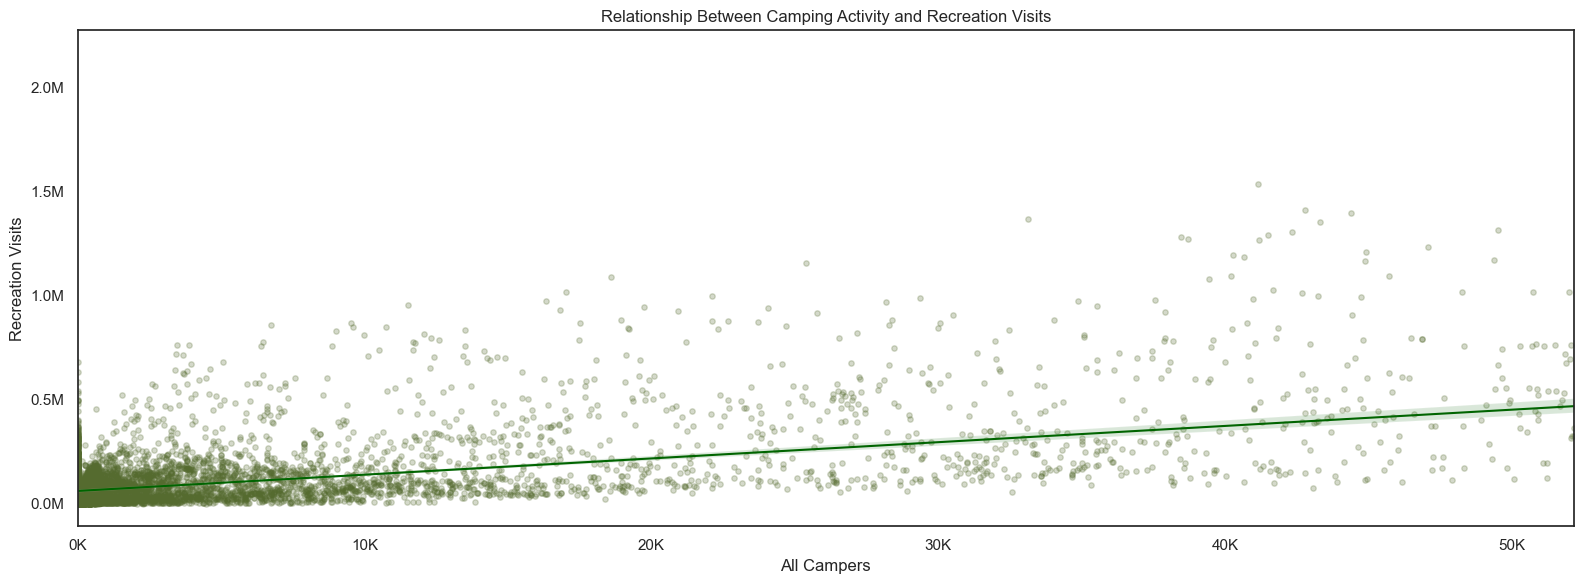

In [92]:
clean_visits['All Campers'] = clean_visits['RV Campers'] + clean_visits['Tent Campers'] + clean_visits['Backcountry']

plt.figure(figsize=(16, 6))
#slim x-axis to where majority of data is
camp_vis = sns.regplot(x='All Campers',y='Recreation Visits',data=clean_visits,color='darkolivegreen',scatter_kws={'alpha': 0.25,'s': 15}, line_kws={'color':'darkgreen', 'linewidth':1.5})
plt.title('Relationship Between Camping Activity and Recreation Visits')
plt.xlabel('All Campers')
plt.ylabel('Recreation Visits')
#trim x-axis to cut empty whitespace
camp_vis.set_xlim(0,clean_visits['All Campers'].quantile(0.97))
camp_vis.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))
camp_vis.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

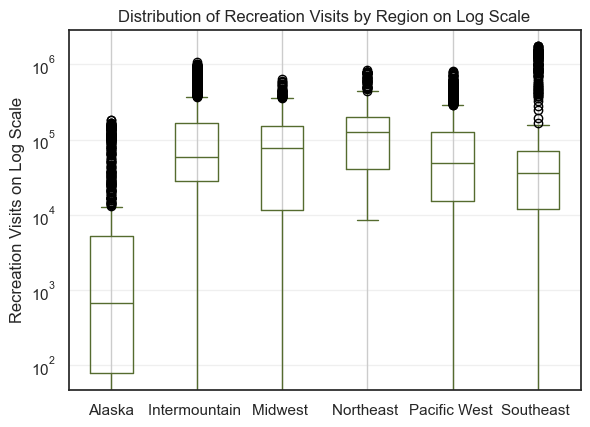

In [79]:
region_visits = clean_visits.groupby('Region')['Recreation Visits'].sum()
plt.figure(figsize=(10,6))
clean_visits.boxplot(column='Recreation Visits',by='Region', color ='darkolivegreen')
plt.yscale('log')
plt.title('Distribution of Recreation Visits by Region on Log Scale')
plt.suptitle('')
plt.xlabel('')
plt.ylabel('Recreation Visits on Log Scale')
plt.grid(axis='y', alpha=0.3)

Text(0, 0.5, 'Total Recreation Visits (2015–2025)')

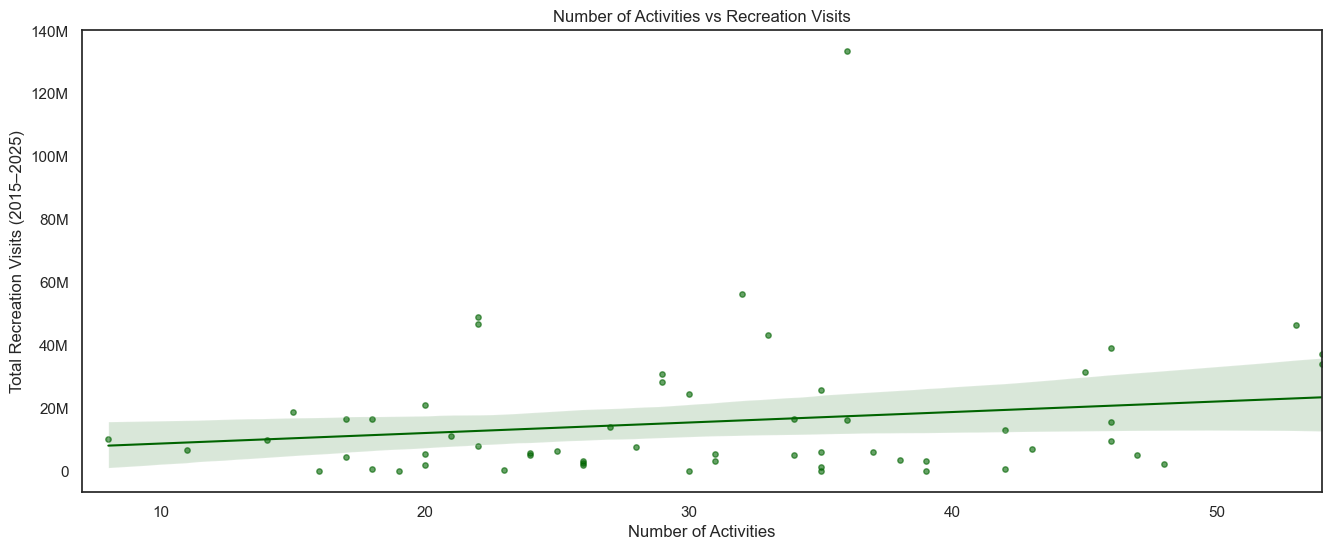

In [107]:
#adding up the visits per park
park_sum = combined.groupby('Park Name').agg({'Recreation Visits':'sum', 'Number of Activities':'first'}).reset_index()
park_sum.head()
#plot visits vs # of activities
plt.figure(figsize=(16,6))
act_vs_vis = sns.regplot(data=park_sum,x= 'Number of Activities', y='Recreation Visits', color= 'darkolivegreen',scatter_kws={'alpha': 0.6,'s': 15, 'color':'darkgreen'}, line_kws={'color':'darkgreen', 'linewidth':1.5})
act_vs_vis.set_xlim(7,combined['Number of Activities'].quantile(0.97))
act_vs_vis.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: '0' if y == 0 else f'{y/1e6:.0f}M'))
plt.title('Number of Activities vs Recreation Visits')
plt.xlabel('Number of Activities')
plt.ylabel('Total Recreation Visits (2015–2025)')

Text(0.5, 0, 'Number of Activities')

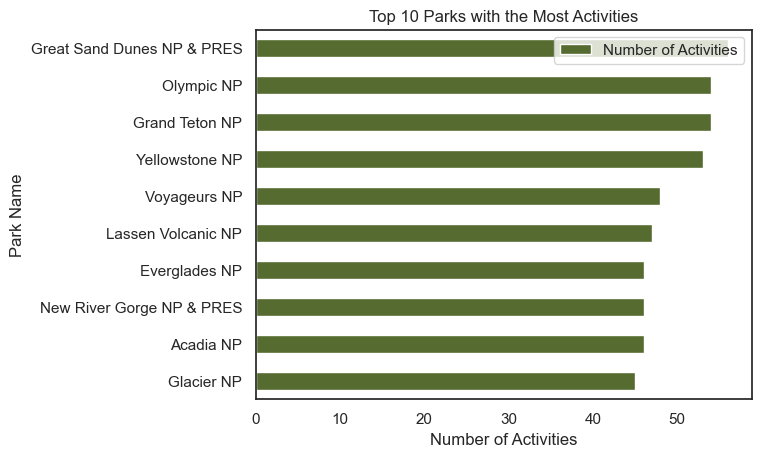

In [82]:
top_act = combined[['Park Name', 'Number of Activities']].sort_values('Number of Activities', ascending = False).drop_duplicates().head(10)
top_act.sort_values('Number of Activities').plot(x='Park Name', y = 'Number of Activities', kind='barh', color='darkolivegreen')
plt.title('Top 10 Parks with the Most Activities')
plt.xlabel('Number of Activities')


Text(0, 0.5, 'Recreation Visits')

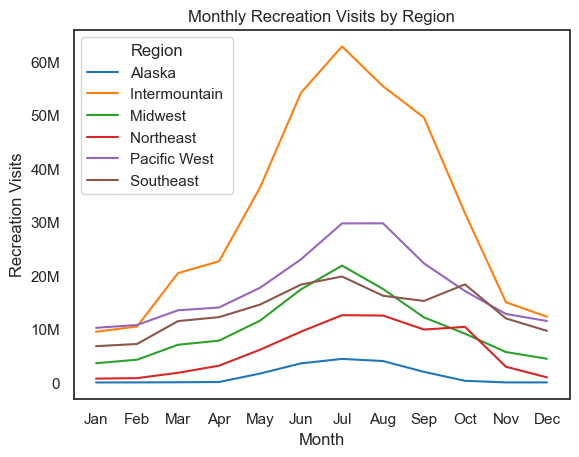

In [108]:
monthly_region = (clean_visits.groupby(['Month','Region'])['Recreation Visits'].sum().reset_index())
months_region=sns.lineplot(data=monthly_region,x='Month',y='Recreation Visits',hue='Region', palette='tab10')
months_region.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: '0' if y == 0 else f'{y/1e6:.0f}M'))
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(ticks=range(1, 13),labels=month_names)
plt.title('Monthly Recreation Visits by Region')
plt.xlabel('Month')
plt.ylabel('Recreation Visits')

Text(0.5, 1.0, 'Correlation Matrix')

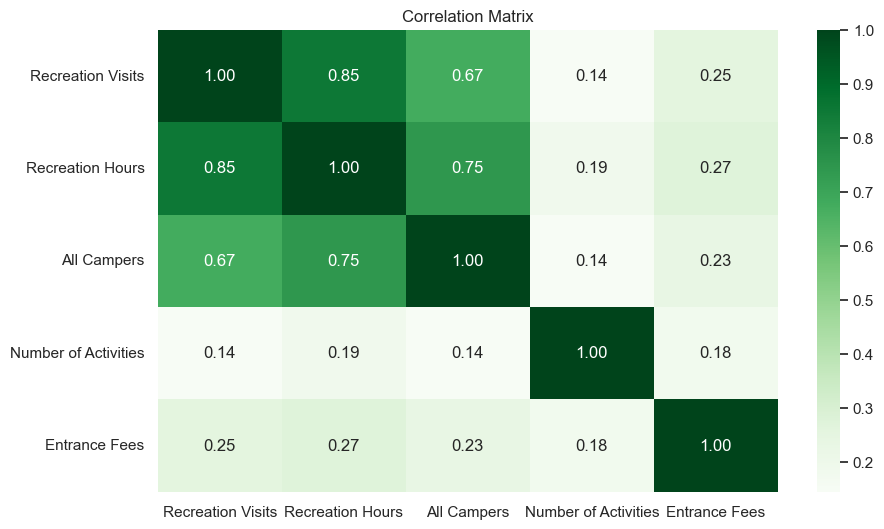

In [40]:
corr_vars = combined[['Recreation Visits','Recreation Hours','All Campers','Number of Activities','Entrance Fees']]
corr_matrix = corr_vars.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,annot=True,cmap='Greens',fmt='.2f')
plt.title('Correlation Matrix')

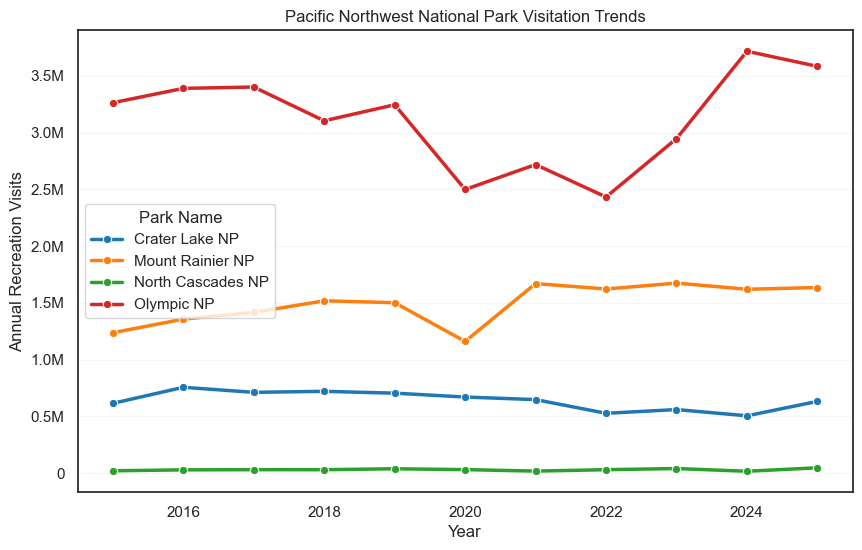

In [110]:
pnw = ['Olympic NP', 'Mount Rainier NP', 'Crater Lake NP', 'North Cascades NP']
pnw_vis = clean_visits[clean_visits['Park Name'].isin(pnw)]
pnw_yearly = (pnw_vis.groupby(['Year', 'Park Name'])['Recreation Visits'].sum().reset_index())
plt.figure(figsize=(10,6))
pnw_plt= sns.lineplot(data=pnw_yearly,x='Year',y='Recreation Visits',hue='Park Name', marker='o', linewidth=2.5,palette='tab10')
pnw_plt.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: '0' if y == 0 else f'{y/1e6:.1f}M'))
plt.title('Pacific Northwest National Park Visitation Trends')
plt.xlabel('Year')
plt.ylabel('Annual Recreation Visits')
plt.grid(axis='y', color='lightgray', alpha=0.2)
plt.show()

In [87]:
pnw_yearly[pnw_yearly['Park Name'] == 'North Cascades NP'] #major diff in visitation compared to other PNW parks

,Year,Park Name,Recreation Visits
2,2015,North Cascades NP,20677
6,2016,North Cascades NP,28646
10,2017,North Cascades NP,30326
14,2018,North Cascades NP,30085
18,2019,North Cascades NP,38208
22,2020,North Cascades NP,30885
26,2021,North Cascades NP,17855
30,2022,North Cascades NP,30154
34,2023,North Cascades NP,40351
38,2024,North Cascades NP,16485
